In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from pathlib import Path
from typing import List

In [2]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")

# Example: print or pass them into other analysis
# print(core_processed_files)


In [3]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_sum = {extract_flight_number(f) for f in flight_sum_files}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in flight_sum_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [4]:
ds_height = xr.open_dataset(filtered_nc[0])
ds_height_ressampled = ds_height.resample(Time="1min").mean()
ds_height_ressampled

<xarray.Dataset> Size: 5MB
Dimensions:         (data_point: 431, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                     sps64: 64)
Coordinates:
  * data_point      (data_point) datetime64[ns] 3kB 2012-09-18T08:52:00 ... 2...
Dimensions without coordinates: sps32, sps04, sps01, sps02, sps64
Data variables: (12/140)
    IAS_RVSM        (data_point, sps32) float32 55kB 0.0 0.0 0.0 ... 11.9 11.87
    IAS_RVSM_FLAG   (data_point, sps32) float32 55kB 3.0 3.0 3.0 ... 0.0 0.0 0.0
    TAS_RVSM        (data_point, sps32) float32 55kB 0.0 0.0 0.0 ... 12.33 12.3
    TAS_RVSM_FLAG   (data_point, sps32) float32 55kB 3.0 3.0 3.0 ... 1.0 1.0 1.0
    TAT_DI_R        (data_point, sps32) float32 55kB 0.0 0.0 0.0 ... 306.2 306.2
    TAT_DI_R_FLAG   (data_point, sps32) float32 55kB 3.0 3.0 3.0 ... 1.0 1.0 1.0
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 2kB nan nan ... 0.3841 0.4042
    TDEW_C_U_FLAG   (data_point, sps01) float32 2kB 3.0 3.0 3.0 ... 0.0 0.0 0.0
    U_NOTURB        (data_point, sps01) float32 2kB nan nan ... 0.6499 0.2066
    U_NOTURB_FLAG   (data_point, sps01) float32 2kB 3.0 3.0 3.0 ... 0.95 1.273
    V_NOTURB        (data_point, sps01) float32 2kB nan nan ... -2.633 -1.128
    V_NOTURB_FLAG   (data_point, sps01) float32 2kB 3.0 3.0 3.0 ... 0.95 1.273
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

In [24]:
height_radar = ds_height_ressampled['HGT_RADR'].values
np.shape(height_radar)

(431, 2)

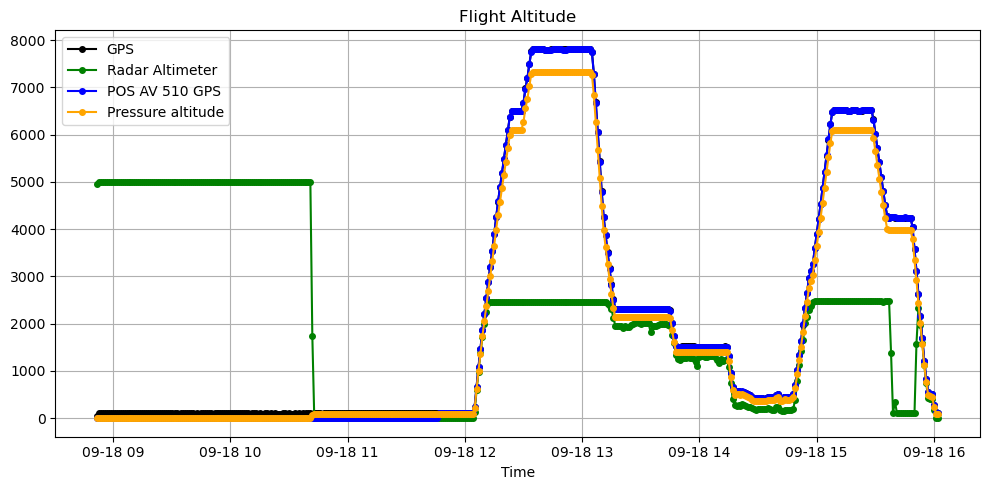

In [25]:
# Aggregate to shape (431,)
gps = ds_height_ressampled['GPS_ALT']  # Already (431,)
hgt_radr = ds_height_ressampled['HGT_RADR'].mean(axis=1)  # From (431, 2) → (431,)
alt_gin = ds_height_ressampled['ALT_GIN'].mean(axis=1)    # From (431, 32) → (431,)
palt_rvs = ds_height_ressampled['PALT_RVS'].mean(axis=1)  # From (431, 32) → (431,)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

time = ds_height_ressampled['data_point']

ax.plot(time, gps, label='GPS', marker='o', linestyle='-', markersize=4, color='black')
ax.plot(time, hgt_radr, label='Radar Altimeter', marker='o', linestyle='-', markersize=4, color='green')
ax.plot(time, alt_gin, label='POS AV 510 GPS', marker='o', linestyle='-', markersize=4, color='blue')
ax.plot(time, palt_rvs, label='Pressure altitude', marker='o', linestyle='-', markersize=4, color='orange')

ax.set_xlabel("Time")
ax.set_title("Flight Altitude")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()